<a href="https://colab.research.google.com/github/abyansyah052/softcomp-fuzz-ann/blob/master/IGDFuzz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUZZY LOGIC - PRIORITAS PEMERIKSAAN PASIEN IGD RINGAN
Input: Nyeri (0-10), Suhu Tubuh (degC), Lama Tunggu (menit)
Output: Prioritas Pemeriksaan (0-100)

In [ ]:
!pip install -U scikit-fuzzy

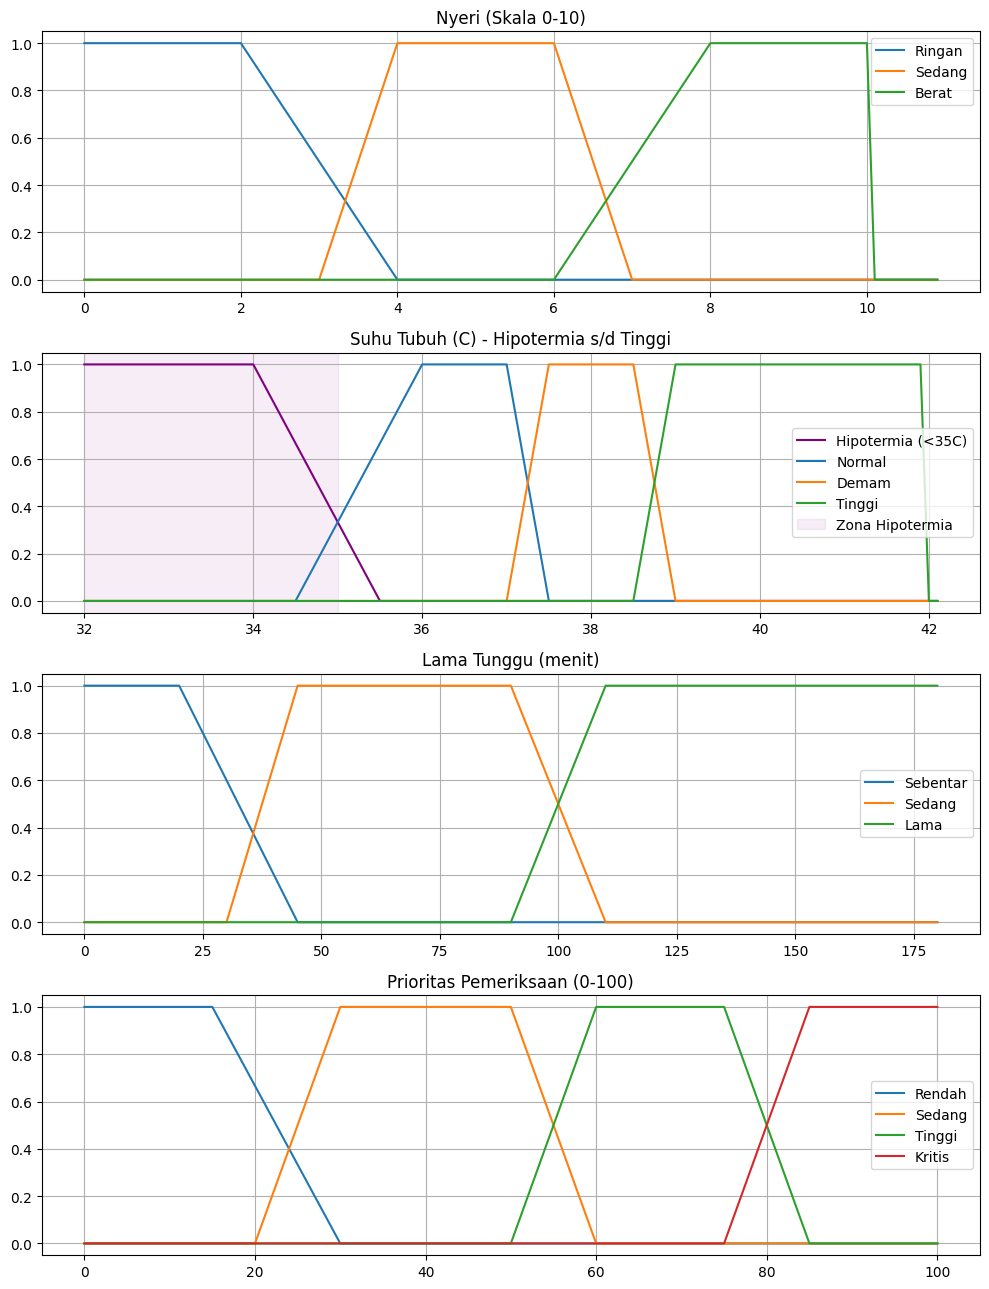

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

x_nyeri  = np.arange(0, 11, 0.1)
x_suhu   = np.arange(32, 42.1, 0.1)
x_tunggu = np.arange(0, 181, 1.0)
x_prior  = np.arange(0, 101, 1.0)

mf_nyeri_ringan = fuzz.trapmf(x_nyeri, [0, 0, 2, 4])
mf_nyeri_sedang = fuzz.trapmf(x_nyeri, [3, 4, 6, 7])
mf_nyeri_berat  = fuzz.trapmf(x_nyeri, [6, 8, 10, 10])

mf_suhu_hipo   = fuzz.trapmf(x_suhu, [32.0, 32.0, 34.0, 35.5])
mf_suhu_normal = fuzz.trapmf(x_suhu, [34.5, 36.0, 37.0, 37.5])
mf_suhu_demam  = fuzz.trapmf(x_suhu, [37.0, 37.5, 38.5, 39.0])
mf_suhu_tinggi = fuzz.trapmf(x_suhu, [38.5, 39.0, 42.0, 42.0])

mf_tunggu_sebentar = fuzz.trapmf(x_tunggu, [0, 0, 20, 45])
mf_tunggu_sedang   = fuzz.trapmf(x_tunggu, [30, 45, 90, 110])
mf_tunggu_lama     = fuzz.trapmf(x_tunggu, [90, 110, 180, 180])

mf_rendah   = fuzz.trapmf(x_prior, [0, 0, 15, 30])
mf_sedang_p = fuzz.trapmf(x_prior, [20, 30, 50, 60])
mf_tinggi   = fuzz.trapmf(x_prior, [50, 60, 75, 85])
mf_kritis   = fuzz.trapmf(x_prior, [75, 85, 100, 100])

fig, ax = plt.subplots(4, 1, figsize=(10, 13))

ax[0].plot(x_nyeri, mf_nyeri_ringan, label='Ringan')
ax[0].plot(x_nyeri, mf_nyeri_sedang, label='Sedang')
ax[0].plot(x_nyeri, mf_nyeri_berat, label='Berat')
ax[0].set_title('Nyeri (Skala 0-10)'); ax[0].legend(); ax[0].grid(True)

ax[1].plot(x_suhu, mf_suhu_hipo, label='Hipotermia (<35C)', color='purple')
ax[1].plot(x_suhu, mf_suhu_normal, label='Normal')
ax[1].plot(x_suhu, mf_suhu_demam, label='Demam')
ax[1].plot(x_suhu, mf_suhu_tinggi, label='Tinggi')
ax[1].axvspan(32, 35, alpha=0.07, color='purple', label='Zona Hipotermia')
ax[1].set_title('Suhu Tubuh (C) - Hipotermia s/d Tinggi'); ax[1].legend(); ax[1].grid(True)

ax[2].plot(x_tunggu, mf_tunggu_sebentar, label='Sebentar')
ax[2].plot(x_tunggu, mf_tunggu_sedang, label='Sedang')
ax[2].plot(x_tunggu, mf_tunggu_lama, label='Lama')
ax[2].set_title('Lama Tunggu (menit)'); ax[2].legend(); ax[2].grid(True)

ax[3].plot(x_prior, mf_rendah, label='Rendah')
ax[3].plot(x_prior, mf_sedang_p, label='Sedang')
ax[3].plot(x_prior, mf_tinggi, label='Tinggi')
ax[3].plot(x_prior, mf_kritis, label='Kritis')
ax[3].set_title('Prioritas Pemeriksaan (0-100)'); ax[3].legend(); ax[3].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
nyeri  = float(input('Tingkat nyeri pasien (0-10) interval 3   : '))
suhu   = float(input('Suhu tubuh pasien (32-42 C)     : '))
tunggu = float(input('Lama tunggu pasien (0-180 mnt)  : '))

nyeri  = float(np.clip(nyeri,  0.0,  10.0))
suhu   = float(np.clip(suhu,  32.0,  42.0))
tunggu = float(np.clip(tunggu, 0.0, 180.0))

deg_ringan   = fuzz.interp_membership(x_nyeri, mf_nyeri_ringan, nyeri)
deg_sedang_n = fuzz.interp_membership(x_nyeri, mf_nyeri_sedang, nyeri)
deg_berat    = fuzz.interp_membership(x_nyeri, mf_nyeri_berat, nyeri)

deg_hipo   = fuzz.interp_membership(x_suhu, mf_suhu_hipo, suhu)
deg_normal = fuzz.interp_membership(x_suhu, mf_suhu_normal, suhu)
deg_demam  = fuzz.interp_membership(x_suhu, mf_suhu_demam, suhu)
deg_panas  = fuzz.interp_membership(x_suhu, mf_suhu_tinggi, suhu)

deg_sebentar = fuzz.interp_membership(x_tunggu, mf_tunggu_sebentar, tunggu)
deg_sedang_t = fuzz.interp_membership(x_tunggu, mf_tunggu_sedang, tunggu)
deg_lama     = fuzz.interp_membership(x_tunggu, mf_tunggu_lama, tunggu)

print(f'Input: nyeri={nyeri}, suhu={suhu}, tunggu={tunggu}')
print(f'Nyeri  -> Ringan={deg_ringan:.2f} | Sedang={deg_sedang_n:.2f} | Berat={deg_berat:.2f}')
print(f'Suhu   -> Hipo={deg_hipo:.2f} | Normal={deg_normal:.2f} | Demam={deg_demam:.2f} | Tinggi={deg_panas:.2f}')
print(f'Tunggu -> Sebentar={deg_sebentar:.2f} | Sedang={deg_sedang_t:.2f} | Lama={deg_lama:.2f}')

Tingkat nyeri pasien (0-10) interval 3   : 5
Suhu tubuh pasien (32-42 C)     : 12
Lama tunggu pasien (0-180 mnt)  : 20
Input: nyeri=5.0, suhu=32.0, tunggu=20.0
Nyeri  -> Ringan=0.00 | Sedang=1.00 | Berat=0.00
Suhu   -> Hipo=1.00 | Normal=0.00 | Demam=0.00 | Tinggi=0.00
Tunggu -> Sebentar=1.00 | Sedang=0.00 | Lama=0.00


In [ ]:
rule_data = [
    (min(deg_ringan, deg_hipo, deg_sebentar), mf_tinggi),
    (min(deg_ringan, deg_hipo, deg_sedang_t), mf_tinggi),
    (min(deg_ringan, deg_hipo, deg_lama), mf_kritis),
    (min(deg_sedang_n, deg_hipo, deg_sebentar), mf_tinggi),
    (min(deg_sedang_n, deg_hipo, deg_sedang_t), mf_kritis),
    (min(deg_sedang_n, deg_hipo, deg_lama), mf_kritis),
    (min(deg_berat, deg_hipo, deg_sebentar), mf_kritis),
    (min(deg_berat, deg_hipo, deg_sedang_t), mf_kritis),
    (min(deg_berat, deg_hipo, deg_lama), mf_kritis),

    (min(deg_ringan, deg_normal, deg_sebentar), mf_rendah),
    (min(deg_ringan, deg_normal, deg_sedang_t), mf_rendah),
    (min(deg_ringan, deg_normal, deg_lama), mf_sedang_p),
    (min(deg_sedang_n, deg_normal, deg_sebentar), mf_rendah),
    (min(deg_sedang_n, deg_normal, deg_sedang_t), mf_sedang_p),
    (min(deg_sedang_n, deg_normal, deg_lama), mf_tinggi),
    (min(deg_berat, deg_normal, deg_sebentar), mf_sedang_p),
    (min(deg_berat, deg_normal, deg_sedang_t), mf_tinggi),
    (min(deg_berat, deg_normal, deg_lama), mf_kritis),

    (min(deg_ringan, deg_demam, deg_sebentar), mf_rendah),
    (min(deg_ringan, deg_demam, deg_sedang_t), mf_sedang_p),
    (min(deg_ringan, deg_demam, deg_lama), mf_sedang_p),
    (min(deg_sedang_n, deg_demam, deg_sebentar), mf_sedang_p),
    (min(deg_sedang_n, deg_demam, deg_sedang_t), mf_sedang_p),
    (min(deg_sedang_n, deg_demam, deg_lama), mf_tinggi),
    (min(deg_berat, deg_demam, deg_sebentar), mf_tinggi),
    (min(deg_berat, deg_demam, deg_sedang_t), mf_tinggi),
    (min(deg_berat, deg_demam, deg_lama), mf_kritis),

    (min(deg_ringan, deg_panas, deg_sebentar), mf_sedang_p),
    (min(deg_ringan, deg_panas, deg_sedang_t), mf_sedang_p),
    (min(deg_ringan, deg_panas, deg_lama), mf_tinggi),
    (min(deg_sedang_n, deg_panas, deg_sebentar), mf_sedang_p),
    (min(deg_sedang_n, deg_panas, deg_sedang_t), mf_tinggi),
    (min(deg_sedang_n, deg_panas, deg_lama), mf_kritis),
    (min(deg_berat, deg_panas, deg_sebentar), mf_tinggi),
    (min(deg_berat, deg_panas, deg_sedang_t), mf_kritis),
    (min(deg_berat, deg_panas, deg_lama), mf_kritis),
]

rules = [np.fmin(w, mf_out) for w, mf_out in rule_data]
agregasi = np.maximum.reduce(rules)

print('Done')

Done


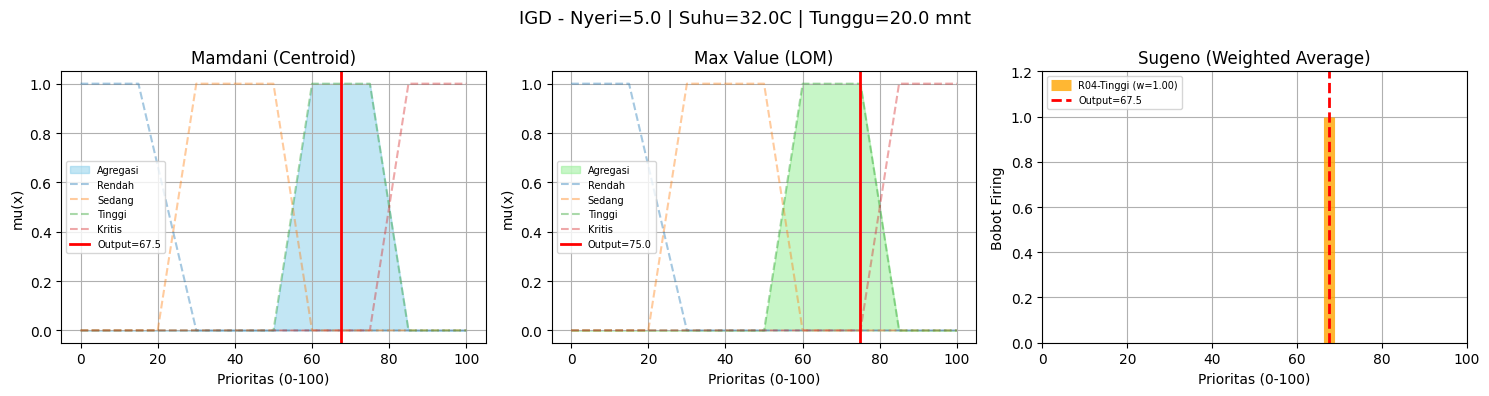

Mamdani   : 67.5 -> TINGGI
Max Value : 75.0 -> KRITIS
Sugeno    : 67.5 -> TINGGI

Tabel Perbandingan Hasil:
Metode                       |   Nilai | Kategori
----------------------------------------------------
Mamdani (Centroid)           |    67.5 | TINGGI 
Max Value (LOM)              |    75.0 | KRITIS 
Sugeno (Weighted Average)    |    67.5 | TINGGI 


In [ ]:
hasil_mamdani = fuzz.defuzz(x_prior, agregasi, 'centroid')
hasil_lom = fuzz.defuzz(x_prior, agregasi, 'lom')

rule_meta = [
    (min(deg_ringan, deg_hipo, deg_sebentar), 67.5, 'R01-Tinggi', 'orange'),
    (min(deg_ringan, deg_hipo, deg_sedang_t), 67.5, 'R02-Tinggi', 'orange'),
    (min(deg_ringan, deg_hipo, deg_lama), 92.5, 'R03-Kritis', 'red'),
    (min(deg_sedang_n, deg_hipo, deg_sebentar), 67.5, 'R04-Tinggi', 'orange'),
    (min(deg_sedang_n, deg_hipo, deg_sedang_t), 92.5, 'R05-Kritis', 'red'),
    (min(deg_sedang_n, deg_hipo, deg_lama), 92.5, 'R06-Kritis', 'red'),
    (min(deg_berat, deg_hipo, deg_sebentar), 92.5, 'R07-Kritis', 'red'),
    (min(deg_berat, deg_hipo, deg_sedang_t), 92.5, 'R08-Kritis', 'red'),
    (min(deg_berat, deg_hipo, deg_lama), 92.5, 'R09-Kritis', 'red'),

    (min(deg_ringan, deg_normal, deg_sebentar), 7.5, 'R10-Rendah', 'blue'),
    (min(deg_ringan, deg_normal, deg_sedang_t), 7.5, 'R11-Rendah', 'blue'),
    (min(deg_ringan, deg_normal, deg_lama), 40.0, 'R12-Sedang', 'green'),
    (min(deg_sedang_n, deg_normal, deg_sebentar), 7.5, 'R13-Rendah', 'blue'),
    (min(deg_sedang_n, deg_normal, deg_sedang_t), 40.0, 'R14-Sedang', 'green'),
    (min(deg_sedang_n, deg_normal, deg_lama), 67.5, 'R15-Tinggi', 'orange'),
    (min(deg_berat, deg_normal, deg_sebentar), 40.0, 'R16-Sedang', 'green'),
    (min(deg_berat, deg_normal, deg_sedang_t), 67.5, 'R17-Tinggi', 'orange'),
    (min(deg_berat, deg_normal, deg_lama), 92.5, 'R18-Kritis', 'red'),

    (min(deg_ringan, deg_demam, deg_sebentar), 7.5, 'R19-Rendah', 'blue'),
    (min(deg_ringan, deg_demam, deg_sedang_t), 40.0, 'R20-Sedang', 'green'),
    (min(deg_ringan, deg_demam, deg_lama), 40.0, 'R21-Sedang', 'green'),
    (min(deg_sedang_n, deg_demam, deg_sebentar), 40.0, 'R22-Sedang', 'green'),
    (min(deg_sedang_n, deg_demam, deg_sedang_t), 40.0, 'R23-Sedang', 'green'),
    (min(deg_sedang_n, deg_demam, deg_lama), 67.5, 'R24-Tinggi', 'orange'),
    (min(deg_berat, deg_demam, deg_sebentar), 67.5, 'R25-Tinggi', 'orange'),
    (min(deg_berat, deg_demam, deg_sedang_t), 67.5, 'R26-Tinggi', 'orange'),
    (min(deg_berat, deg_demam, deg_lama), 92.5, 'R27-Kritis', 'red'),

    (min(deg_ringan, deg_panas, deg_sebentar), 40.0, 'R28-Sedang', 'green'),
    (min(deg_ringan, deg_panas, deg_sedang_t), 40.0, 'R29-Sedang', 'green'),
    (min(deg_ringan, deg_panas, deg_lama), 67.5, 'R30-Tinggi', 'orange'),
    (min(deg_sedang_n, deg_panas, deg_sebentar), 40.0, 'R31-Sedang', 'green'),
    (min(deg_sedang_n, deg_panas, deg_sedang_t), 67.5, 'R32-Tinggi', 'orange'),
    (min(deg_sedang_n, deg_panas, deg_lama), 92.5, 'R33-Kritis', 'red'),
    (min(deg_berat, deg_panas, deg_sebentar), 67.5, 'R34-Tinggi', 'orange'),
    (min(deg_berat, deg_panas, deg_sedang_t), 92.5, 'R35-Kritis', 'red'),
    (min(deg_berat, deg_panas, deg_lama), 92.5, 'R36-Kritis', 'red'),
]

bobot = [w for w, _, _, _ in rule_meta]
singleton = [z for _, z, _, _ in rule_meta]
numerator = sum(w * z for w, z in zip(bobot, singleton))
denominator = sum(bobot)
hasil_sugeno = numerator / denominator if denominator != 0 else 0

label_mamdani = 'RENDAH' if hasil_mamdani < 25 else 'SEDANG' if hasil_mamdani < 50 else 'TINGGI' if hasil_mamdani < 75 else 'KRITIS'
label_lom = 'RENDAH' if hasil_lom < 25 else 'SEDANG' if hasil_lom < 50 else 'TINGGI' if hasil_lom < 75 else 'KRITIS'
label_sugeno = 'RENDAH' if hasil_sugeno < 25 else 'SEDANG' if hasil_sugeno < 50 else 'TINGGI' if hasil_sugeno < 75 else 'KRITIS'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].fill_between(x_prior, agregasi, alpha=0.5, color='skyblue', label='Agregasi')
axes[0].plot(x_prior, mf_rendah, '--', alpha=0.4, label='Rendah')
axes[0].plot(x_prior, mf_sedang_p, '--', alpha=0.4, label='Sedang')
axes[0].plot(x_prior, mf_tinggi, '--', alpha=0.4, label='Tinggi')
axes[0].plot(x_prior, mf_kritis, '--', alpha=0.4, label='Kritis')
axes[0].axvline(hasil_mamdani, color='red', linewidth=2, label=f'Output={hasil_mamdani:.1f}')
axes[0].set_title('Mamdani (Centroid)')
axes[0].set_xlabel('Prioritas (0-100)')
axes[0].set_ylabel('mu(x)')
axes[0].legend(fontsize=7)
axes[0].grid(True)

axes[1].fill_between(x_prior, agregasi, alpha=0.5, color='lightgreen', label='Agregasi')
axes[1].plot(x_prior, mf_rendah, '--', alpha=0.4, label='Rendah')
axes[1].plot(x_prior, mf_sedang_p, '--', alpha=0.4, label='Sedang')
axes[1].plot(x_prior, mf_tinggi, '--', alpha=0.4, label='Tinggi')
axes[1].plot(x_prior, mf_kritis, '--', alpha=0.4, label='Kritis')
axes[1].axvline(hasil_lom, color='red', linewidth=2, label=f'Output={hasil_lom:.1f}')
axes[1].set_title('Max Value (LOM)')
axes[1].set_xlabel('Prioritas (0-100)')
axes[1].set_ylabel('mu(x)')
axes[1].legend(fontsize=7)
axes[1].grid(True)

seen = {}
for w, z, lbl, color in rule_meta:
    if w > 0:
        if z not in seen or w > seen[z][0]:
            seen[z] = (w, lbl, color)

for z, (w, lbl, color) in seen.items():
    axes[2].vlines(z, 0, w, linewidth=8, color=color, alpha=0.8, label=f'{lbl} (w={w:.2f})')


axes[2].axvline(hasil_sugeno, color='red', linewidth=2, linestyle='--', label=f'Output={hasil_sugeno:.1f}')
axes[2].set_title('Sugeno (Weighted Average)')
axes[2].set_xlabel('Prioritas (0-100)')
axes[2].set_ylabel('Bobot Firing')
axes[2].set_xlim(0, 100)
axes[2].set_ylim(0, 1.2)
axes[2].legend(fontsize=7)
axes[2].grid(True)

plt.suptitle(f'IGD - Nyeri={nyeri} | Suhu={suhu}C | Tunggu={tunggu} mnt', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mamdani   : {hasil_mamdani:.1f} -> {label_mamdani}')
print(f'Max Value : {hasil_lom:.1f} -> {label_lom}')
print(f'Sugeno    : {hasil_sugeno:.1f} -> {label_sugeno}')

# Tabel perbandingan hasil
hasil_perbandingan = [
    ('Mamdani (Centroid)', hasil_mamdani, label_mamdani),
    ('Max Value (LOM)', hasil_lom, label_lom),
    ('Sugeno (Weighted Average)', hasil_sugeno, label_sugeno),
]

print('\nTabel Perbandingan Hasil:')
print(f"{'Metode':<28} | {'Nilai':>7} | {'Kategori':<7}")
print('-' * 52)
for metode, nilai, kategori in hasil_perbandingan:
    print(f"{metode:<28} | {nilai:>7.1f} | {kategori:<7}")